In [33]:
import numpy as np
import scipy.io as sio
import torch
import torch.nn as nn
import torch.optim as optim
from torch_geometric.nn import GCNConv
from torch_geometric.utils import from_scipy_sparse_matrix
from sklearn.metrics import roc_auc_score
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

In [34]:
mat_data = sio.loadmat('ACM.mat')

X = mat_data['Attributes'].toarray()  # Node attributes (dense array)
A_sparse = mat_data['Network']  # Adjacency matrix (sparse)
labels = mat_data['Label'].flatten()  # Node labels (anomaly labels)

# Convert sparse adjacency matrix to edge index format for PyTorch Geometric
edge_index, edge_weight = from_scipy_sparse_matrix(A_sparse)

# Convert to PyTorch tensors
X_tensor = torch.FloatTensor(X)
labels_tensor = torch.LongTensor(labels)

print(f"Dataset loaded:")
print(f"Number of nodes: {X.shape[0]}")
print(f"Number of features: {X.shape[1]}")
print(f"Number of edges: {edge_index.shape[1]}")
print(f"Number of anomalies: {labels.sum()}")
print(f"Anomaly ratio: {labels.sum() / len(labels):.2%}")

Dataset loaded:
Number of nodes: 16484
Number of features: 8337
Number of edges: 164350
Number of anomalies: 597
Anomaly ratio: 3.62%


In [35]:
class Encoder(nn.Module):
    """
    encodes both structure and node attributes.
    Architecture: input -> 128 -> 64
    """
    def __init__(self, input_dim, hidden_dim=128, latent_dim=64):
        super(Encoder, self).__init__()
        self.conv1 = GCNConv(input_dim, hidden_dim)
        self.conv2 = GCNConv(hidden_dim, latent_dim)
    
    def forward(self, x, edge_index):
        # First GCN layer
        x = self.conv1(x, edge_index)
        x = torch.relu(x)
        
        # Second GCN layer
        x = self.conv2(x, edge_index)
        x = torch.relu(x)
        
        return x


class AttributeDecoder(nn.Module):
    """
    reconstructs node attributes from latent representations.
    Architecture: 64 -> 128 -> output_dim (reversed encoder)
    """
    def __init__(self, latent_dim=64, hidden_dim=128, output_dim=None):
        super(AttributeDecoder, self).__init__()
        self.conv1 = GCNConv(latent_dim, hidden_dim)
        self.conv2 = GCNConv(hidden_dim, output_dim)
    
    def forward(self, z, edge_index):
        # First GCN layer
        x = self.conv1(z, edge_index)
        x = torch.relu(x)
        
        # Second GCN layer (reconstruction)
        x = self.conv2(x, edge_index)
        
        return x


class StructureDecoder(nn.Module):
    """
    reconstructs adjacency matrix from latent representations.
    Uses Z @ Z^T to reconstruct the adjacency matrix.
    """
    def __init__(self, latent_dim=64):
        super(StructureDecoder, self).__init__()
        self.conv = GCNConv(latent_dim, latent_dim)
    
    def forward(self, z, edge_index):
        # GCN layer to keep latent dimension
        z = self.conv(z, edge_index)
        z = torch.relu(z)
        
        # Reconstruct adjacency matrix: A_hat = Z @ Z^T
        A_hat = torch.matmul(z, z.t())
        
        return A_hat


class GraphAutoencoder(nn.Module):
    def __init__(self, input_dim, hidden_dim=128, latent_dim=64):
        super(GraphAutoencoder, self).__init__()
        self.encoder = Encoder(input_dim, hidden_dim, latent_dim)
        self.attr_decoder = AttributeDecoder(latent_dim, hidden_dim, input_dim)
        self.struct_decoder = StructureDecoder(latent_dim)
    
    def forward(self, x, edge_index):
        # Encode
        z = self.encoder(x, edge_index)
        
        # Decode attributes
        x_hat = self.attr_decoder(z, edge_index)
        
        # Decode structure
        A_hat = self.struct_decoder(z, edge_index)
        
        return x_hat, A_hat


In [36]:
def custom_loss(X, X_hat, A, A_hat, alpha=0.8):
    """
    Args:
        X: Original node attributes
        X_hat: Reconstructed node attributes
        A: Original adjacency matrix
        A_hat: Reconstructed adjacency matrix
        alpha: Balance parameter (default: 0.8)

    Returns:
        Total loss value
    """
    # Frobenius norm squared 
    attr_loss = torch.norm(X - X_hat, p="fro") ** 2
    struct_loss = torch.norm(A - A_hat, p="fro") ** 2

    # Combined loss
    total_loss = alpha * attr_loss + (1 - alpha) * struct_loss

    return total_loss, attr_loss, struct_loss


print("Custom loss function defined!")

Custom loss function defined!


In [37]:
input_dim = X.shape[1]
model = GraphAutoencoder(input_dim=input_dim, hidden_dim=128, latent_dim=64)

optimizer = optim.Adam(model.parameters(), lr=0.004)

# Convert adjacency matrix to dense tensor for loss calculation
A_dense = torch.FloatTensor(A_sparse.toarray())

# Alpha parameter for loss function
alpha = 0.8

print(f"Model initialized:")
print(f"Input dimension: {input_dim}")
print(f"Alpha: {alpha}")

Model initialized:
Input dimension: 8337
Alpha: 0.8


In [38]:
# training parameters
num_epochs = 50

# training history
loss_history = []
attr_loss_history = []
struct_loss_history = []
roc_auc_history = []
epoch_roc_auc = []

print("Starting training...\n")

for epoch in range(num_epochs):
    model.train()
    optimizer.zero_grad()

    # get reconstructions
    X_hat, A_hat = model(X_tensor, edge_index)

    # compute loss
    total_loss, attr_loss, struct_loss = custom_loss(
        X_tensor, X_hat, A_dense, A_hat, alpha
    )

    # compute gradients
    total_loss.backward()

    # update weights
    optimizer.step()

    # Store loss values
    loss_history.append(total_loss.item())
    attr_loss_history.append(attr_loss.item())
    struct_loss_history.append(struct_loss.item())

    # compute ROC AUC every 5 epochs
    if (epoch + 1) % 5 == 0:
        model.eval()
        with torch.no_grad():
            X_hat_eval, A_hat_eval = model(X_tensor, edge_index)

            # compute reconstruction errors as anomaly scores
            # Attribute reconstruction error (per node)
            attr_errors = torch.norm(X_tensor - X_hat_eval, p=2, dim=1).numpy()

            # Structure reconstruction error (per node)
            A_errors = torch.norm(A_dense - A_hat_eval, p=2, dim=1).numpy()

            # Combined reconstruction error
            reconstruction_errors = alpha * attr_errors + (1 - alpha) * A_errors

            # Compute ROC AUC score
            roc_auc = roc_auc_score(labels, reconstruction_errors)
            roc_auc_history.append(roc_auc)
            epoch_roc_auc.append(epoch + 1)

            print(
                f"Epoch {epoch+1:3d}/{num_epochs} | "
                f"Loss: {total_loss.item():.4f} | "
                f"Attr Loss: {attr_loss.item():.4f} | "
                f"Struct Loss: {struct_loss.item():.4f} | "
                f"ROC AUC: {roc_auc:.4f}"
            )

print("Training completed!")

Starting training...

Epoch   5/50 | Loss: 40066.6172 | Attr Loss: 9039.0332 | Struct Loss: 164176.9531 | ROC AUC: 0.8949
Epoch  10/50 | Loss: 39608.7461 | Attr Loss: 8512.1680 | Struct Loss: 163995.0625 | ROC AUC: 0.8949
Epoch  15/50 | Loss: 39680.5156 | Attr Loss: 8614.6562 | Struct Loss: 163943.9375 | ROC AUC: 0.8946
Epoch  20/50 | Loss: 39611.0820 | Attr Loss: 8538.1904 | Struct Loss: 163902.6562 | ROC AUC: 0.8946
Epoch  25/50 | Loss: 39649.4141 | Attr Loss: 8608.1143 | Struct Loss: 163814.6094 | ROC AUC: 0.8945
Epoch  30/50 | Loss: 39612.2969 | Attr Loss: 8550.3555 | Struct Loss: 163860.0625 | ROC AUC: 0.8946
Epoch  35/50 | Loss: 39633.9219 | Attr Loss: 8593.0273 | Struct Loss: 163797.4844 | ROC AUC: 0.8945
Epoch  40/50 | Loss: 39583.8984 | Attr Loss: 8558.7480 | Struct Loss: 163684.5000 | ROC AUC: 0.8946
Epoch  45/50 | Loss: 39542.4180 | Attr Loss: 8577.4287 | Struct Loss: 163402.3750 | ROC AUC: 0.8947
Epoch  50/50 | Loss: 39511.8789 | Attr Loss: 8558.9619 | Struct Loss: 163323.5

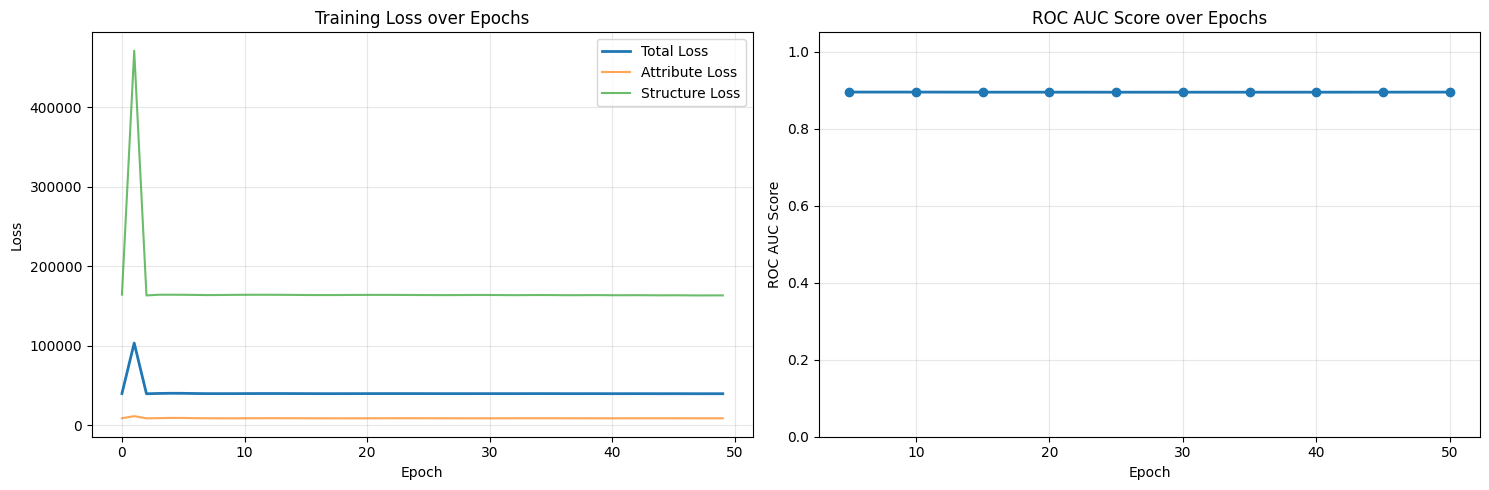

Final Results:
Final Total Loss: 39511.8789
Final Attribute Loss: 8558.9619
Final Structure Loss: 163323.5469
Final ROC AUC: 0.8948


In [39]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Plot 1: Loss curves
axes[0].plot(loss_history, label='Total Loss', linewidth=2)
axes[0].plot(attr_loss_history, label='Attribute Loss', alpha=0.7)
axes[0].plot(struct_loss_history, label='Structure Loss', alpha=0.7)
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].set_title('Training Loss over Epochs')
axes[0].legend()
axes[0].grid(alpha=0.3)

# Plot 2: ROC AUC score
axes[1].plot(epoch_roc_auc, roc_auc_history, marker='o', linewidth=2, markersize=6)
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('ROC AUC Score')
axes[1].set_title('ROC AUC Score over Epochs')
axes[1].grid(alpha=0.3)
axes[1].set_ylim([0, 1.05])

plt.tight_layout()
plt.show()

print(f"Final Results:")
print(f"Final Total Loss: {loss_history[-1]:.4f}")
print(f"Final Attribute Loss: {attr_loss_history[-1]:.4f}")
print(f"Final Structure Loss: {struct_loss_history[-1]:.4f}")
print(f"Final ROC AUC: {roc_auc_history[-1]:.4f}")

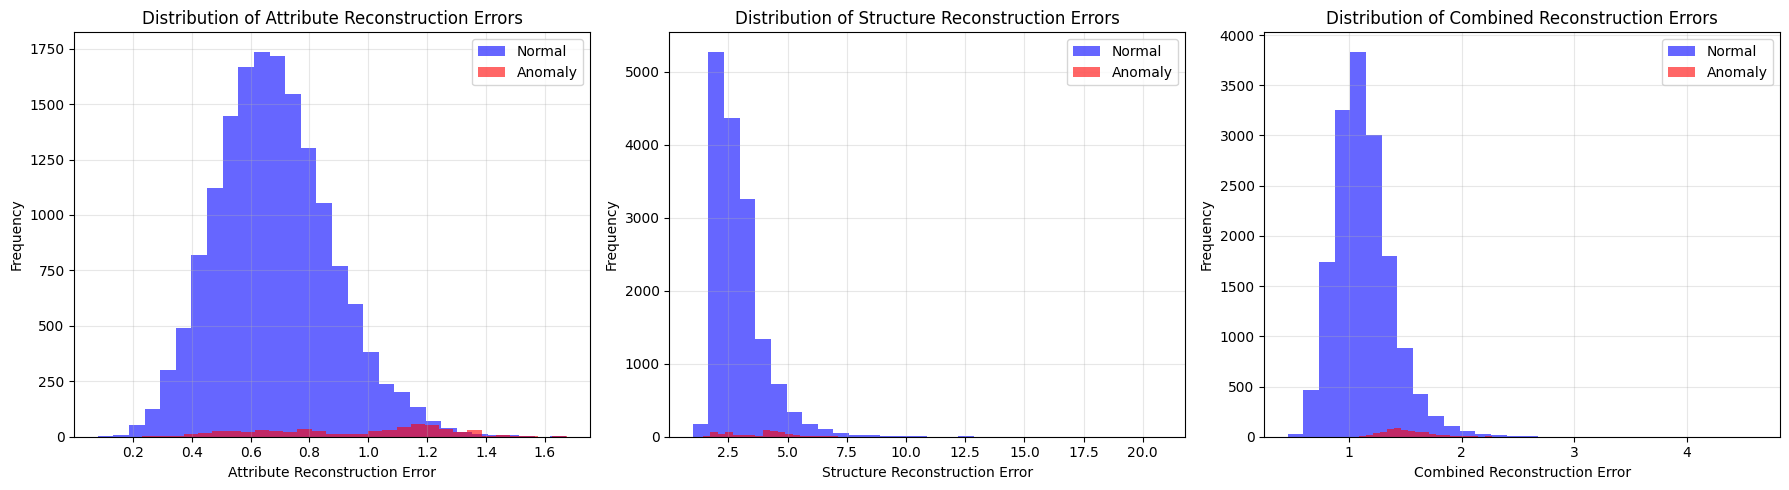


Reconstruction Error Statistics:
Normal nodes:
Mean error: 1.1290
Std error: 0.2606

Anomalous nodes:
Mean error: 1.5299
Std error: 0.2342


In [40]:
# Final evaluation
model.eval()
with torch.no_grad():
    X_hat_final, A_hat_final = model(X_tensor, edge_index)
    
    # Compute reconstruction errors
    attr_errors_final = torch.norm(X_tensor - X_hat_final, p=2, dim=1).numpy()
    struct_errors_final = torch.norm(A_dense - A_hat_final, p=2, dim=1).numpy()
    total_errors_final = alpha * attr_errors_final + (1 - alpha) * struct_errors_final

# Separate errors by normal vs anomaly
normal_errors = total_errors_final[labels == 0]
anomaly_errors = total_errors_final[labels == 1]

# Plot error distributions
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Plot 1: Attribute errors
axes[0].hist(attr_errors_final[labels == 0], bins=30, alpha=0.6, label='Normal', color='blue')
axes[0].hist(attr_errors_final[labels == 1], bins=30, alpha=0.6, label='Anomaly', color='red')
axes[0].set_xlabel('Attribute Reconstruction Error')
axes[0].set_ylabel('Frequency')
axes[0].set_title('Distribution of Attribute Reconstruction Errors')
axes[0].legend()
axes[0].grid(alpha=0.3)

# Plot 2: Structure errors
axes[1].hist(struct_errors_final[labels == 0], bins=30, alpha=0.6, label='Normal', color='blue')
axes[1].hist(struct_errors_final[labels == 1], bins=30, alpha=0.6, label='Anomaly', color='red')
axes[1].set_xlabel('Structure Reconstruction Error')
axes[1].set_ylabel('Frequency')
axes[1].set_title('Distribution of Structure Reconstruction Errors')
axes[1].legend()
axes[1].grid(alpha=0.3)

# Plot 3: Combined errors
axes[2].hist(normal_errors, bins=30, alpha=0.6, label='Normal', color='blue')
axes[2].hist(anomaly_errors, bins=30, alpha=0.6, label='Anomaly', color='red')
axes[2].set_xlabel('Combined Reconstruction Error')
axes[2].set_ylabel('Frequency')
axes[2].set_title('Distribution of Combined Reconstruction Errors')
axes[2].legend()
axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\nReconstruction Error Statistics:")
print(f"Normal nodes:")
print(f"Mean error: {normal_errors.mean():.4f}")
print(f"Std error: {normal_errors.std():.4f}")
print(f"\nAnomalous nodes:")
print(f"Mean error: {anomaly_errors.mean():.4f}")
print(f"Std error: {anomaly_errors.std():.4f}")

In [41]:
# top anomalous nodes based on reconstruction error
top_k = 10
top_indices = np.argsort(total_errors_final)[-top_k:][::-1]

print(f"Top {top_k} nodes with highest reconstruction errors:\n")
print(f"{'Rank':<6} {'Node ID':<10} {'Error':<12} {'True Label':<12}")
print("-" * 45)
for rank, idx in enumerate(top_indices, 1):
    true_label = "Anomaly" if labels[idx] == 1 else "Normal"
    print(f"{rank:<6} {idx:<10} {total_errors_final[idx]:<12.4f} {true_label:<12}")

# Calculate precision at k
true_anomalies_in_top_k = sum(labels[top_indices])
precision_at_k = true_anomalies_in_top_k / top_k
print(f"\nPrecision@{top_k}: {precision_at_k:.2%}")
print(f"  ({true_anomalies_in_top_k} out of {top_k} top predictions are true anomalies)")

Top 10 nodes with highest reconstruction errors:

Rank   Node ID    Error        True Label  
---------------------------------------------
1      5418       4.6177       Normal      
2      13934      3.3487       Normal      
3      8500       3.3253       Normal      
4      3737       3.2204       Normal      
5      97         3.2099       Normal      
6      5985       3.0283       Normal      
7      7892       2.9619       Normal      
8      13389      2.9558       Anomaly     
9      16195      2.8754       Normal      
10     7278       2.8468       Normal      

Precision@10: 10.00%
  (1 out of 10 top predictions are true anomalies)
